# Анализ данных велопроката
**Автор:** Мария Сазыкина  
**Дата:** Июль 2026  
**Данные:** Seoul Bike Sharing Demand Dataset, 8 760 наблюдений  
(почасовые данные за 2017–2018 гг., Сеул, Южная Корея)  
**Инструменты:** Python, pandas, matplotlib

---

## Ключевые находки

1. **Велопрокат — транспорт, не досуг.** Два пика спроса в 8ч и 18ч совпадают с началом и концом рабочего дня. В будние дни пики в 2–3 раза выше чем в праздники.

2. **Погода влияет умеренно (корреляция 0.45).** Летом спрос в 4.5 раза выше чем зимой. Температура — главный погодный фактор, но рабочий ритм важнее погоды.

3. **Спрос стабилен по дням недели.** Пик — пятница (745 аренд/час), минимум — воскресенье (624). Разница всего 16% — базовый спрос есть в любой день.

**Вывод:** велопрокат — транспортный сервис с погодной сезонностью.  
Планирование парка должно учитывать рабочий ритм (час + день недели)  
и температурный прогноз.

---

## 1. Контекст и данные

**Объект анализа:** сервис велопроката в Сеуле (Южная Корея).  
**Цель:** выявить паттерны спроса для оптимизации управления парком велосипедов.  
**Данные:** почасовые наблюдения за 2017–2018 годы. Каждая строка — один час одного дня.

**Столбцы:**
- `Date`, `Hour` — дата и час наблюдения
- `Temperature`, `Humidity`, `Wind speed`, `Rainfall`, `Snowfall` — погодные условия
- `Seasons`, `Holiday`, `Functioning Day` — контекстные признаки
- `Partner 1`, `Partner 2` — количество арендованных велосипедов у двух партнёров

In [24]:
# Загрузка библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib

# Загрузка данных
df = pd.read_csv('BikeData.csv')
print(f'Размер датасета: {df.shape[0]} строк, {df.shape[1]} столбцов')
display(df.head())
print(df.info())

Размер датасета: 8760 строк, 12 столбцов


,Date,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Seasons,Holiday,Functioning Day,Partner 1,Partner 2
0,01/12/2017,0,-5.2,37,2.2,0.0,0.0,Winter,No Holiday,Yes,207,50
1,01/12/2017,1,-5.5,38,0.8,0.0,0.0,Winter,No Holiday,Yes,139,80
2,01/12/2017,2,-6.0,39,1.0,0.0,0.0,Winter,No Holiday,Yes,22,140
3,01/12/2017,3,-6.2,40,0.9,0.0,0.0,Winter,No Holiday,Yes,43,105
4,01/12/2017,4,-6.0,36,2.3,0.0,0.0,Winter,No Holiday,Yes,59,38


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8760 entries, 0 to 8759
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Date             8760 non-null   object 
 1   Hour             8760 non-null   int64  
 2   Temperature      8581 non-null   float64
 3   Humidity         8760 non-null   int64  
 4   Wind speed       8760 non-null   float64
 5   Rainfall         8760 non-null   float64
 6   Snowfall         8760 non-null   float64
 7   Seasons          8760 non-null   object 
 8   Holiday          8760 non-null   object 
 9   Functioning Day  8760 non-null   object 
 10  Partner 1        8760 non-null   int64  
 11  Partner 2        8760 non-null   int64  
dtypes: float64(4), int64(4), object(4)
memory usage: 821.4+ KB
None


In [4]:
df.isna().sum() # Пропущенные значения



,0
Date,0
Hour,0
Temperature,179
Humidity,0
Wind speed,0
Rainfall,0
Snowfall,0
Seasons,0
Holiday,0
Functioning Day,0


In [5]:
df.describe().round(2) # Информация о датасете

,Hour,Temperature,Humidity,Wind speed,Rainfall,Snowfall,Partner 1,Partner 2
count,8760.00,8581.00,8760.00,8760.00,8760.00,8760.00,8760.00,8760.00
mean,11.50,12.88,58.23,1.72,0.15,0.08,345.66,350.93
std,6.92,11.96,20.36,1.04,1.13,0.44,415.82,425.69
min,0.00,-17.80,0.00,0.00,0.00,0.00,0.00,0.00
25%,5.75,3.40,42.00,0.90,0.00,0.00,57.00,56.00
50%,11.50,13.70,57.00,1.50,0.00,0.00,186.00,182.00
75%,17.25,22.50,74.00,2.30,0.00,0.00,487.00,499.25
max,23.00,39.40,98.00,7.40,35.00,8.80,3101.00,3039.00


**Наблюдения:**
- Датасет содержит 8760 строк — ровно 365 дней × 24 часа, данные полные по времени
- Пропуски только в столбце `Temperature` — 179 значений (2% от данных)
- Среднее и медиана температуры близки → распределение симметрично → заполним средним
- Дата загружена как текст (`object`) — нужна конвертация

## 2. Подготовка данных

Перед анализом необходимо:
1. Конвертировать дату из текста в формат datetime
2. Создать итоговый столбец спроса `Total` = Partner 1 + Partner 2
3. Заполнить пропуски в температуре средним значением (обоснование: среднее ≈ медиане, распределение симметрично)
4. Проверить результат

In [25]:
# 1. Конвертация даты
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

# 2. Общий спрос
df['Total'] = df['Partner 1'] + df['Partner 2']

# 3. Заполнение пропусков температуры
temp_mean = df['Temperature'].mean().round(2)
df['Temperature'] = df['Temperature'].fillna(temp_mean)

# 4. Проверка
print(f'Пропусков после заполнения: {df["Temperature"].isna().sum()}')
print(f'Тип столбца Date: {df["Date"].dtype}')
print(f'Средний спрос (Total): {df["Total"].mean():.0f} аренд/час')

Пропусков после заполнения: 0
Тип столбца Date: datetime64[ns]
Средний спрос (Total): 697 аренд/час


**Результат подготовки:**
- Дата конвертирована в datetime — теперь можно группировать по месяцам и дням недели
- Столбец `Total` создан — отражает совокупный спрос обоих партнёров
- Пропуски в температуре заполнены средним значением (~12°C)
- Данные готовы к анализу

## 3. Паттерны спроса по времени суток

**Гипотеза:** велопрокат используется преимущественно как транспорт
для поездок на работу и учёбу, а не для досуга.

**Почему это важно:** понимание характера использования определяет
всю операционную стратегию — где держать велосипеды, когда и сколько.

**Ожидаемый результат:** два пика спроса — утром (~8ч) и вечером (~18ч),
более выраженные в будние дни, чем в праздники.

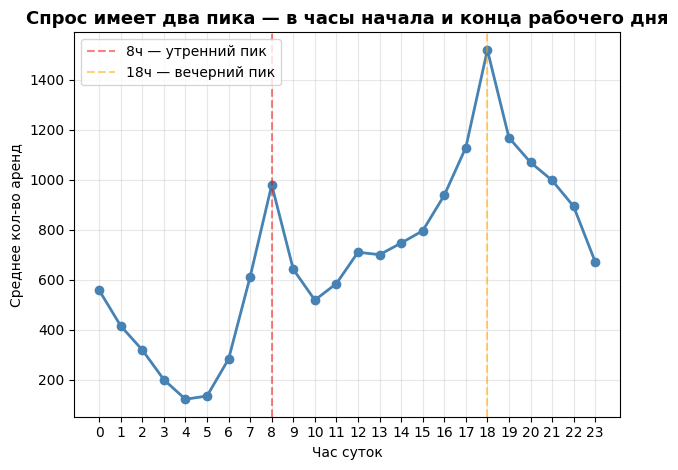

Час максимального спроса: 18ч (1519 аренд в среднем)
Час минимального спроса: 4ч (123 аренд в среднем)


In [8]:
# Средний спрос по часам суток
hourly = df.groupby('Hour')['Total'].mean()

fig, ax = plt.subplots()
ax.plot(hourly.index, hourly.values, marker='o', linewidth=2, color='steelblue')
ax.set_title('Спрос имеет два пика — в часы начала и конца рабочего дня',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Час суток')
ax.set_ylabel('Среднее кол-во аренд')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)

# Отметим пики
peak_morning = hourly.idxmax() if hourly[:12].max() > hourly[12:].max() else hourly[:12].idxmax()
ax.axvline(x=8, color='red', linestyle='--', alpha=0.5, label='8ч — утренний пик')
ax.axvline(x=18, color='orange', linestyle='--', alpha=0.5, label='18ч — вечерний пик')
ax.legend()
plt.tight_layout()
plt.show()

print(f'Час максимального спроса: {hourly.idxmax()}ч ({hourly.max():.0f} аренд в среднем)')
print(f'Час минимального спроса: {hourly.idxmin()}ч ({hourly.min():.0f} аренд в среднем)')

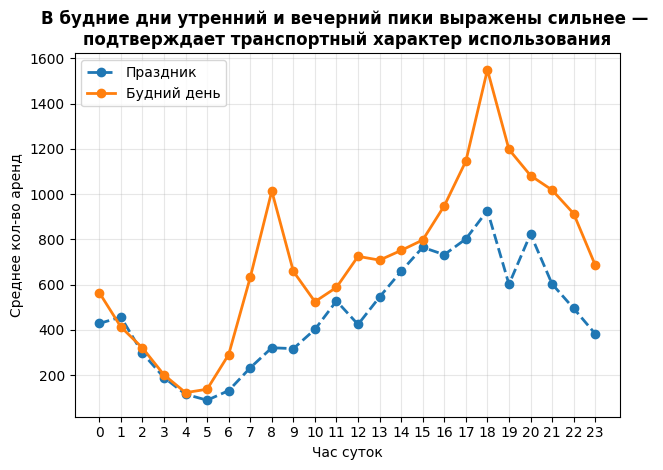

In [9]:
# Сравнение будни vs праздники
hourly_by_holiday = df.groupby(['Hour', 'Holiday'])['Total'].mean().unstack()

fig, ax = plt.subplots()
for col in hourly_by_holiday.columns:
    label = 'Праздник' if col == 'Holiday' else 'Будний день'
    style = '--' if col == 'Holiday' else '-'
    ax.plot(hourly_by_holiday.index, hourly_by_holiday[col],
            marker='o', linestyle=style, linewidth=2, label=label)

ax.set_title('В будние дни утренний и вечерний пики выражены сильнее — \nподтверждает транспортный характер использования',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Час суток')
ax.set_ylabel('Среднее кол-во аренд')
ax.set_xticks(range(0, 24))
ax.grid(True, alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

**Вывод: гипотеза подтверждена ✓**

- Два чётких пика: ~8ч (начало рабочего дня) и ~18ч (конец рабочего дня)
- В будние дни пики выражены значительно сильнее, чем в праздники
- В праздники спрос более равномерный и смещён на дневные часы (прогулки)

**Бизнес-значение:** велопрокат — это транспортный сервис, а не досуговый.
Это означает, что наличие велосипедов критично именно в часы пик буднего дня.
Рекомендация: концентрировать максимальный парк на 7-9ч и 17-19ч в будние дни.

## 4. Сезонность и влияние погоды

**Гипотеза:** спрос на велопрокат зависит от погодных условий —
в тёплые сезоны выше, в холодные ниже.

**Ожидаемый результат:** летом максимальный спрос, зимой минимальный.
Умеренная корреляция с температурой (погода — один из факторов, но не единственный).

/tmp/ipykernel_602/549854369.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Весна', 'Лето', 'Осень', 'Зима'])


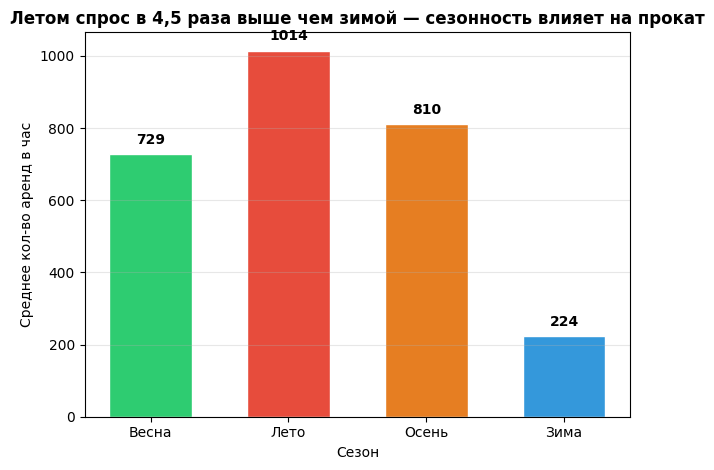

Средний спрос по сезонам:
  Весна: 729 аренд/час
  Лето: 1014 аренд/час
  Осень: 810 аренд/час
  Зима: 224 аренд/час


In [26]:
# Средний спрос по сезонам
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
seasonal = df.groupby('Seasons')['Total'].mean().reindex(season_order)

fig, ax = plt.subplots()
bars = ax.bar(seasonal.index, seasonal.values,
              color=['#2ecc71', '#e74c3c', '#e67e22', '#3498db'],
              width=0.6, edgecolor='white')

# Подписи значений на столбиках
for bar, val in zip(bars, seasonal.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
            f'{val:.0f}', ha='center', va='bottom', fontweight='bold')

ax.set_title('Летом спрос в 4,5 раза выше чем зимой — сезонность влияет на прокат',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Сезон')
ax.set_ylabel('Среднее кол-во аренд в час')
ax.set_xticklabels(['Весна', 'Лето', 'Осень', 'Зима'])
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print('Средний спрос по сезонам:')
for season, val in zip(['Весна', 'Лето', 'Осень', 'Зима'], seasonal.values):
    print(f'  {season}: {val:.0f} аренд/час')

In [12]:
# Корреляция температуры со спросом
corr = df['Temperature'].corr(df['Total'])

print(f'Корреляция температуры и спроса: {corr:.3f}')
print()
print('Интерпретация:')
if corr < 0.3:
    print('  Слабая связь')
elif corr < 0.5:
    print('  Умеренная связь — температура влияет, но не определяет спрос')
elif corr < 0.7:
    print('  Заметная связь')
else:
    print('  Сильная связь')

# Корреляции других погодных факторов
weather_cols = ['Temperature', 'Humidity', 'Wind speed', 'Rainfall', 'Snowfall']
print('\nКорреляция всех погодных факторов со спросом:')
for col in weather_cols:
    c = df[col].corr(df['Total'])
    print(f'  {col}: {c:.3f}')

Корреляция температуры и спроса: 0.451

Интерпретация:
  Умеренная связь — температура влияет, но не определяет спрос

Корреляция всех погодных факторов со спросом:
  Temperature: 0.451
  Humidity: -0.169
  Wind speed: 0.098
  Rainfall: -0.104
  Snowfall: -0.121


**Вывод: гипотеза подтверждена частично ✓**

- Летом спрос в ~4.5 раза выше чем зимой — сезонность реальна и значительна
- Корреляция температуры со спросом: **0.45 (умеренная)**
- Из всех погодных факторов **температура влияет сильнее всего** (0.45) —
  осадки (-0.10), влажность (-0.17) и ветер (0.10) значительно слабее
- Температура — значимый фактор, но не единственный

## 5. Спрос по дням недели

**Гипотеза:** спрос распределён неравномерно по дням недели —
в рабочие дни выше из-за транспортного использования,
в выходные ниже или смещён.

**Ожидаемый результат:** понедельник-пятница выше субботы-воскресенья.

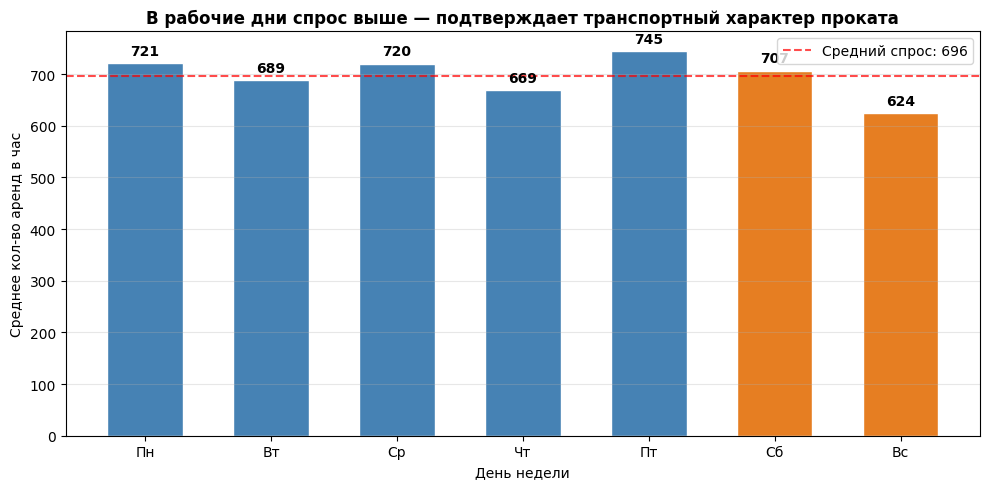


Самый загруженный день: Пт
Самый тихий день: Вс


In [20]:
# Добавляем день недели
df['Weekday'] = df['Date'].dt.dayofweek  # 0=Пн, 6=Вс
df['Weekday_name'] = df['Date'].dt.day_name()

# Средний спрос по дням недели
day_order = [0, 1, 2, 3, 4, 5, 6]
day_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']

weekly = df.groupby('Weekday')['Total'].mean().reindex(day_order)

# Цвета: рабочие дни — синий, выходные — оранжевый
colors = ['steelblue'] * 5 + ['#e67e22'] * 2

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(day_labels, weekly.values,
              color=colors, edgecolor='white', width=0.6)

# Подписи значений
for bar, val in zip(bars, weekly.values):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 10,
            f'{val:.0f}', ha='center', va='bottom',
            fontweight='bold', fontsize=10)

# Линия среднего
avg = weekly.mean()
ax.axhline(y=avg, color='red', linestyle='--',
           alpha=0.7, label=f'Средний спрос: {avg:.0f}')

ax.set_title('В рабочие дни спрос выше — подтверждает транспортный характер проката',
             fontsize=12, fontweight='bold')
ax.set_xlabel('День недели')
ax.set_ylabel('Среднее кол-во аренд в час')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f'\nСамый загруженный день: {day_labels[weekly.argmax()]}')
print(f'Самый тихий день: {day_labels[weekly.argmin()]}')

**Вывод: гипотеза подтверждена частично ✓**

- Самый загруженный день: **Пятница (745 аренд/час)**
- Самый тихий день: **Воскресенье (624 аренд/час)**
- Разница всего 16% — спрос стабилен в течение недели
- Суббота (707) близка к рабочим дням — возможно субботняя занятость

**Связь с гипотезой 1:**  
Пики по часам + пики по дням дают единую картину —  
велопрокат используется как транспорт преимущественно в будние дни,  
но базовый спрос есть в любой день.

**Бизнес-значение:** техосмотр и обслуживание велосипедов  
оптимально планировать на воскресенье — минимальный спрос,  
простой парка наносит наименьший ущерб.

## 6. Итоговые выводы и рекомендации


В ходе анализа почасовых данных велопроката за 2017–2018 годы  
проверены три гипотезы о природе спроса.

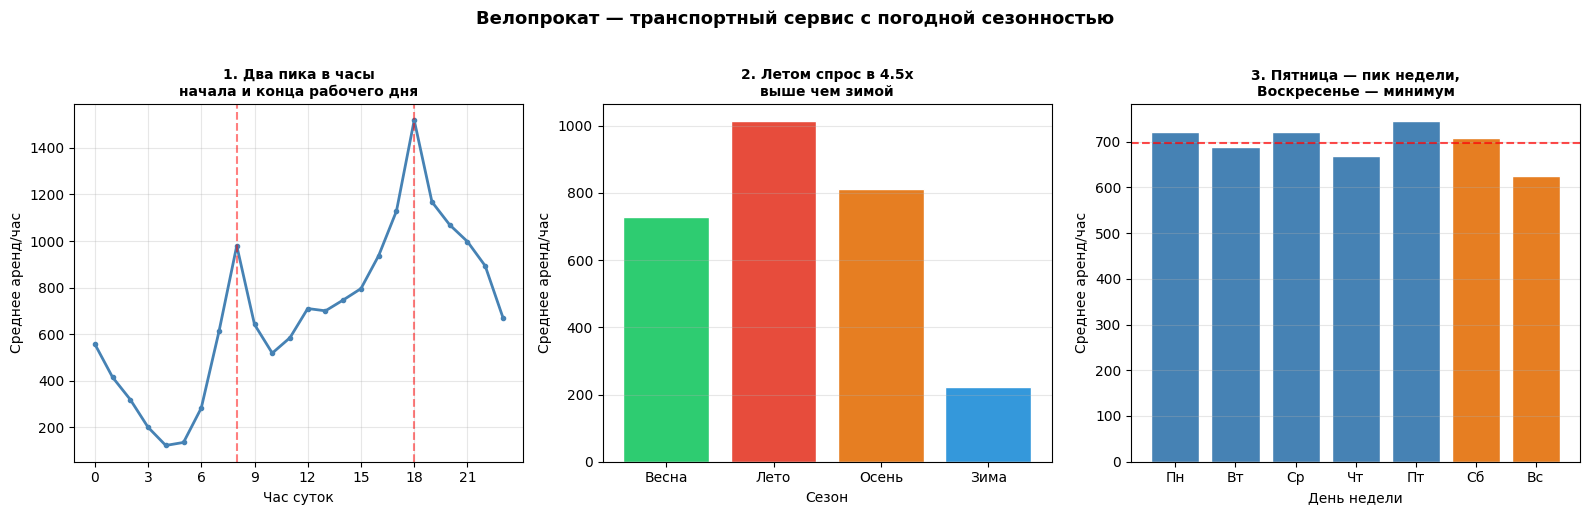

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# График 1: по часам (из раздела 3)
hourly = df.groupby('Hour')['Total'].mean()
axes[0].plot(hourly.index, hourly.values,
             color='steelblue', linewidth=2, marker='o', markersize=3)
axes[0].axvline(x=8, color='red', linestyle='--', alpha=0.5)
axes[0].axvline(x=18, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('1. Два пика в часы\nначала и конца рабочего дня',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('Час суток')
axes[0].set_ylabel('Среднее аренд/час')
axes[0].grid(True, alpha=0.3)
axes[0].set_xticks(range(0, 24, 3))

# График 2: по сезонам (из раздела 4)
season_order = ['Spring', 'Summer', 'Autumn', 'Winter']
season_labels = ['Весна', 'Лето', 'Осень', 'Зима']
seasonal = df.groupby('Seasons')['Total'].mean().reindex(season_order)
axes[1].bar(season_labels, seasonal.values,
            color=['#2ecc71', '#e74c3c', '#e67e22', '#3498db'],
            edgecolor='white')
axes[1].set_title('2. Летом спрос в 4.5x\nвыше чем зимой',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Сезон')
axes[1].set_ylabel('Среднее аренд/час')
axes[1].grid(True, alpha=0.3, axis='y')

# График 3: по дням недели (из раздела 5)
day_labels = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']
weekly = df.groupby('Weekday')['Total'].mean()
colors = ['steelblue'] * 5 + ['#e67e22'] * 2
axes[2].bar(day_labels, weekly.values,
            color=colors, edgecolor='white')
axes[2].axhline(y=weekly.mean(), color='red',
                linestyle='--', alpha=0.7)
axes[2].set_title('3. Пятница — пик недели,\nВоскресенье — минимум',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('День недели')
axes[2].set_ylabel('Среднее аренд/час')
axes[2].grid(True, alpha=0.3, axis='y')

plt.suptitle('Велопрокат — транспортный сервис с погодной сезонностью',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### Ключевые находки

**1. Велопрокат — транспорт, а не досуг**  
Два пика спроса в 8ч и 18ч совпадают с началом и концом рабочего дня.  
В будние дни пики выражены значительно сильнее чем в праздники.  
→ Сервис используется преимущественно для поездок на работу и учёбу.

**2. Погода влияет умеренно (корреляция 0.45)**  
Летом спрос в 4.5 раза выше чем зимой.  
Температура — главный погодный фактор, осадки и ветер влияют слабее.  
→ Погода создаёт сезонный фон, но рабочий ритм важнее.

**3. Спрос стабилен по дням недели**  
Пятница максимальна (745 аренд/час), воскресенье минимально (624).  
Разница всего 16% — без резких провалов в любой день.  
→ Базовый спрос есть всегда, пиковый — в будние дни.

### Синтез

Велопрокат — это **транспортный сервис с погодной сезонностью**.  
Спрос определяется двумя независимыми факторами:  
- **Рабочий ритм** (час суток + день недели) — определяет пики  
- **Погода** (температура, сезон) — определяет базовый уровень

### Рекомендации для бизнеса

| Что | Рекомендация | Обоснование |
|-----|-------------|-------------|
| Управление парком | Максимум велосипедов в 7–9ч и 17–19ч в будние дни | Пиковый спрос 980 и 1519 аренд/час |
| Техобслуживание | Планировать на воскресенье | Минимальный спрос (624 аренды/час) |
| Сезонное планирование | Снижать парк зимой на ~70% | Зима 224 vs Лето 1014 аренд/час |
| Прогнозирование | Использовать прогноз температуры | Корреляция 0.45, главный погодный фактор |
| Маркетинг | Позиционировать как транспорт, не досуг | Пики совпадают с рабочим расписанием |